# ASR Statistics Plots

This notebook compares ASR models with a mixed metric policy for 4-model comparison:
- segmented clips: use cpWER
- non-segmented clips: use WER (labeled as mrs_WER)

Cross-model error per clip $i$ and model $m$:

$$
\text{error}^{\text{cross}}_{i,m}=\begin{cases}
\text{cpWER}_{i,m}, & \text{if segmented} \\
\text{mrs\_WER}_{i,m}, & \text{if non-segmented}
\end{cases}
$$

Condition mean error (for SNR/OVR plots):

$$
\overline{\text{error}}_{m,c}=\frac{1}{N_{m,c}}\sum_{i\in c}\text{error}^{\text{cross}}_{i,m}
$$

The faster-whisper vs whisperx pairwise scatter uses cpWER only.

Average inference time per item (not per batch):

$$
\text{time\_per\_item}_m=\frac{\sum_b \text{duration}_{m,b}}{\sum_b \text{items}_{m,b}}
$$

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.bbox"] = "tight"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "WER_Results_by_Model").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "WER_Results_by_Model"
MANIFEST_PATH = PROJECT_ROOT / "Output" / "manifest.csv"
TIMINGS_PATH = PROJECT_ROOT / "timings_100_random.json"
PLOTS_DIR = PROJECT_ROOT / "Output" / "plot"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

PAIRWISE_CPWER_MODELS = ["faster-whisper", "whisperx"]
MODEL_ORDER = ["faster-whisper", "whisperx", "parakeet", "wav2vec2"]
MODEL_COLORS = {
    "faster-whisper": "#1f77b4",
    "whisperx": "#ff7f0e",
    "parakeet": "#2ca02c",
    "wav2vec2": "#d62728",
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Plots dir: {PLOTS_DIR}")
print(f"Timings file: {TIMINGS_PATH}")

Project root: /home/jamin/Year3Proj
Results dir: /home/jamin/Year3Proj/WER_Results_by_Model
Plots dir: /home/jamin/Year3Proj/Output/plot
Timings file: /home/jamin/Year3Proj/timings_100_random.json


In [2]:
def load_model_results(results_dir: Path = RESULTS_DIR) -> pd.DataFrame:
    rows = []
    for result_path in sorted(results_dir.glob("*_wer_results.json")):
        with open(result_path, "r", encoding="utf-8") as handle:
            payload = json.load(handle)
        model = payload.get("model", result_path.stem.replace("_wer_results", ""))
        for item in payload.get("results", []):
            metrics = item.get("metrics", {}) if item.get("status") == "success" else {}
            row = {
                "model": model,
                "clip_id": item.get("clip_id"),
                "status": item.get("status"),
                "metric_type": item.get("metric_type"),
                "wer_method": item.get("wer_method", np.nan),
                "wer": metrics.get("wer", np.nan),
                "cpwer": metrics.get("cpwer", np.nan),
            }
            rows.append(row)
    return pd.DataFrame(rows)


def _format_snr_label(value) -> str:
    if pd.isna(value):
        return "clean"
    numeric = pd.to_numeric(value, errors="coerce")
    if pd.isna(numeric):
        return str(value)
    return f"{float(numeric):g}"


def load_manifest(manifest_path: Path = MANIFEST_PATH) -> pd.DataFrame:
    manifest = pd.read_csv(manifest_path)
    keep_cols = [col for col in ["clip_id", "overlap_ratio_target", "overlap_ratio_actual", "snr_db", "noise_type"] if col in manifest.columns]
    manifest = manifest[keep_cols].copy()
    if "snr_db" in manifest.columns:
        manifest["snr_label"] = manifest["snr_db"].apply(_format_snr_label)
    if "overlap_ratio_target" in manifest.columns:
        manifest["ovr_label"] = manifest["overlap_ratio_target"].map(lambda value: f"{float(value):.2f}" if pd.notna(value) else "unknown")
    return manifest


def _count_items_from_timing_key(key: str, prefix: str) -> int:
    suffix = key.replace(f"transcribe_{prefix}_", "", 1)
    parts = [chunk for chunk in suffix.split("_-") if chunk]
    return len(parts)


def load_timings(timings_path: Path = TIMINGS_PATH) -> pd.DataFrame:
    with open(timings_path, "r", encoding="utf-8") as handle:
        timings = json.load(handle)
    rows = []
    model_prefixes = {
        "faster-whisper": "faster_whisper",
        "wav2vec2": "wav2vec2",
        "parakeet": "parakeet",
        "whisperx": "whisperx",
    }
    for key, duration in timings.items():
        for model_name, prefix in model_prefixes.items():
            if key.startswith(f"transcribe_{prefix}_"):
                rows.append(
                    {
                        "model": model_name,
                        "duration_sec": float(duration),
                        "item_count": _count_items_from_timing_key(key, prefix),
                        "batch_key": key,
                    }
                )
                break
    return pd.DataFrame(rows)


CROSS_MODEL_CLIP_REGEX = r"(^mix_[0-9]+_0\.(00|14|20|40)_2_7\.4_T$)|(^mix_[0-9]+_0\.14_2_(None|7\.4|0|-5)_T$)"


results_df = load_model_results()
manifest_df = load_manifest()
timings_df = load_timings()

results_df = results_df[results_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)].copy()
manifest_df = manifest_df[manifest_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)].copy()

status_summary_df = (
    results_df.groupby(["model", "status"], as_index=False)["clip_id"]
    .count()
    .rename(columns={"clip_id": "clips"})
)

results_df = results_df.merge(manifest_df, on="clip_id", how="left")

# Cross-model metric policy: cpWER for segmented, mrs_WER (wer field) for non-segmented.
results_df["is_segmented"] = pd.notna(results_df["cpwer"])
results_df["cross_metric_name"] = np.where(results_df["is_segmented"], "cpWER", "mrs_WER")
results_df["cross_model_error"] = np.where(results_df["is_segmented"], results_df["cpwer"], results_df["wer"])
results_df["cross_model_error_clipped"] = results_df["cross_model_error"].clip(upper=1.0)

successful_df = results_df[results_df["status"] == "success"].copy()
successful_df = successful_df[pd.notna(successful_df["cross_model_error"])].copy()

summary_df = (
    successful_df.groupby("model")
    .agg(
        clips=("clip_id", "count"),
        mean_error=("cross_model_error", "mean"),
        median_error=("cross_model_error", "median"),
        mean_error_clipped=("cross_model_error_clipped", "mean"),
        pct_error_gt_1=("cross_model_error", lambda s: 100.0 * (s > 1).mean()),
    )
    .reset_index()
)

metric_breakdown_df = (
    successful_df.groupby(["model", "cross_metric_name"])
    .agg(
        clips=("clip_id", "count"),
        mean_error=("cross_model_error", "mean"),
    )
    .reset_index()
)

method_summary_df = (
    successful_df.dropna(subset=["wer_method"])
    .groupby(["model", "wer_method"], as_index=False)["clip_id"]
    .count()
    .rename(columns={"clip_id": "clips"})
)

print(f"Loaded {len(results_df)} filtered clip results across {results_df['model'].nunique()} models")
print("\nStatus counts after regex filter:")
print(status_summary_df.sort_values(["model", "status"]))
print("\nPer-model cross-metric error summary:")
print(summary_df)
print("\nMetric breakdown (cpWER vs mrs_WER):")
print(metric_breakdown_df.sort_values(["model", "cross_metric_name"]))
if not method_summary_df.empty:
    print("\nWER method usage by model:")
    print(method_summary_df)

missing_success_models = [
    model for model in MODEL_ORDER
    if model in set(results_df["model"]) and model not in set(successful_df["model"])
]
if missing_success_models:
    print("\nWarning: models with zero successful rows in filtered subset:")
    for model in missing_success_models:
        print(f"- {model}")

Loaded 2440 filtered clip results across 4 models

Status counts after regex filter:
            model   status  clips
0  faster-whisper  success    610
1        parakeet  success    610
2        wav2vec2  success    610
3        whisperx  success    610

Per-model cross-metric error summary:
            model  clips  mean_error  median_error  mean_error_clipped  \
0  faster-whisper    610    0.761549      0.772346            0.756725   
1        parakeet    610    0.738455      0.756096            0.738455   
2        wav2vec2    610    0.535551      0.545028            0.535551   
3        whisperx    610    0.731198      0.735577            0.728902   

   pct_error_gt_1  
0        2.131148  
1        0.000000  
2        0.000000  
3        0.819672  

Metric breakdown (cpWER vs mrs_WER):
            model cross_metric_name  clips  mean_error
0  faster-whisper             cpWER    610    0.761549
1        parakeet           mrs_WER    610    0.738455
2        wav2vec2           mrs_

In [3]:
def load_timings(timings_path: Path = TIMINGS_PATH) -> pd.DataFrame:
    with open(timings_path, "r", encoding="utf-8") as handle:
        payload = json.load(handle)

    if isinstance(payload, dict) and "results" in payload:
        timings = pd.DataFrame(payload["results"])
    elif isinstance(payload, list):
        timings = pd.DataFrame(payload)
    elif isinstance(payload, dict):
        rows = []
        for model_name, entry in payload.items():
            if isinstance(entry, dict):
                rows.append({"model": model_name, **entry})
            else:
                rows.append({"model": model_name, "duration_sec": float(entry)})
        timings = pd.DataFrame(rows)
    else:
        timings = pd.DataFrame()

    if timings.empty:
        return timings

    if "item_count" not in timings.columns:
        sample_size = payload.get("sample_size", np.nan) if isinstance(payload, dict) else np.nan
        timings["item_count"] = sample_size

    if "sec_per_item" not in timings.columns and {"duration_sec", "item_count"}.issubset(timings.columns):
        timings["sec_per_item"] = timings["duration_sec"] / timings["item_count"]

    return timings


timings_df = load_timings()
print(f"Loaded timings from {TIMINGS_PATH}")
display(timings_df)

Loaded timings from /home/jamin/Year3Proj/timings_100_random.json


,model,sample_count,duration_sec,sec_per_audio,sample_clip_ids,item_count,sec_per_item
0,faster-whisper,100,979.101264,9.791013,"[mix_0000905_0.14_2_7.4_T, mix_0003254_0.40_2_...",100,9.791013
1,parakeet,100,92.526026,0.925260,"[mix_0000905_0.14_2_7.4_T, mix_0003254_0.40_2_...",100,0.925260
2,wav2vec2,100,52.941335,0.529413,"[mix_0000905_0.14_2_7.4_T, mix_0003254_0.40_2_...",100,0.529413
3,whisperx,100,420.634781,4.206348,"[mix_0000905_0.14_2_7.4_T, mix_0003254_0.40_2_...",100,4.206348


In [4]:
# Top-3 worst performing files per model (using stats_utils helpers).
import sys

code_dir = PROJECT_ROOT / "Code"
if str(code_dir) not in sys.path:
    sys.path.insert(0, str(code_dir))

from stats_utils import load_wer_json, build_analysis_df

worst_rows = []
for result_path in sorted(RESULTS_DIR.glob("*_wer_results.json")):
    payload = load_wer_json(str(result_path))
    model_name = payload.get("model", result_path.stem.replace("_wer_results", ""))

    analysis_df = build_analysis_df(payload, include_failed=False)
    analysis_df = analysis_df[
        analysis_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)
    ].copy()
    if analysis_df.empty:
        continue

    if "model_name" in analysis_df.columns and analysis_df["model_name"].notna().any():
        model_name = analysis_df["model_name"].dropna().iloc[0]

    top3 = (
        analysis_df
        .dropna(subset=["error_value", "clip_id"])
        .sort_values("error_value", ascending=False)
        .head(3)
        .copy()
    )
    if top3.empty:
        continue

    top3["model"] = model_name
    worst_rows.append(
        top3[[
            "model",
            "clip_id",
            "metric_type",
            "error_value",
            "snr_db",
            "overlap_ratio",
            "noise_type",
        ]]
    )

if worst_rows:
    worst_per_model = pd.concat(worst_rows, ignore_index=True)
    worst_per_model = worst_per_model.sort_values(
        ["model", "error_value"], ascending=[True, False]
    ).reset_index(drop=True)

    # Display-friendly SNR label: NaN/None means no-noise condition.
    worst_per_model_display = worst_per_model.copy()
    worst_per_model_display["snr_db"] = worst_per_model_display["snr_db"].apply(
        lambda v: "no noise" if pd.isna(v) else f"{float(v):g}"
    )

    print("Top-3 worst performing files per model (higher error is worse):")
    display(worst_per_model_display)
else:
    print("No successful rows with error values were found after applying CROSS_MODEL_CLIP_REGEX.")

Top-3 worst performing files per model (higher error is worse):


,model,clip_id,metric_type,error_value,snr_db,overlap_ratio,noise_type
0,faster-whisper,mix_0001115_0.14_2_-5_T,cpwer,1.609929,-5,0.14,T
1,faster-whisper,mix_0001109_0.14_2_7.4_T,cpwer,1.468085,7.4,0.14,T
2,faster-whisper,mix_0001106_0.14_2_None_T,cpwer,1.425532,no noise,0.14,T
3,parakeet,mix_0000290_0.14_2_None_T,wer,1.000000,no noise,0.14,T
4,parakeet,mix_0001238_0.14_2_None_T,wer,1.000000,no noise,0.14,T
5,parakeet,mix_0000686_0.14_2_None_T,wer,1.000000,no noise,0.14,T
6,wav2vec2,mix_0000887_0.14_2_-5_T,wer,0.916667,-5,0.14,T
7,wav2vec2,mix_0002801_0.40_2_7.4_T,wer,0.892116,7.4,0.40,T
8,wav2vec2,mix_0003629_0.40_2_7.4_T,wer,0.858238,7.4,0.40,T
9,whisperx,mix_0001226_0.14_2_None_T,cpwer,1.373563,no noise,0.14,T


In [5]:
# Inspect top-3 worst files per model using ref from manifest.csv and hyp from ASR_transcriptions.json.
import ast
import textwrap
from pathlib import Path
from IPython.display import Markdown, display

def _normalize_ws(text):
    if text is None:
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()

def _manifest_transcript_to_text(raw_value):
    text = _normalize_ws(raw_value)
    if not text:
        return ""
    try:
        parsed = ast.literal_eval(text)
    except Exception:
        return text

    pieces = []
    if isinstance(parsed, list):
        for item in parsed:
            if isinstance(item, (list, tuple)) and len(item) >= 2:
                pieces.append(_normalize_ws(item[1]))
            else:
                pieces.append(_normalize_ws(item))
    else:
        pieces.append(_normalize_ws(parsed))
    return " ".join([p for p in pieces if p])

def _hyp_transcript_to_text(raw_value):
    pieces = []
    if isinstance(raw_value, list):
        for item in raw_value:
            if isinstance(item, (list, tuple)) and len(item) >= 2:
                pieces.append(_normalize_ws(item[1]))
            elif isinstance(item, dict):
                pieces.append(_normalize_ws(item.get("text") or item.get("transcript")))
            else:
                pieces.append(_normalize_ws(item))
    elif raw_value is not None:
        pieces.append(_normalize_ws(raw_value))
    return " ".join([p for p in pieces if p])

def _wrap(text, width=120):
    txt = text or ""
    if not txt:
        return "[empty]"
    return "\n".join(textwrap.wrap(txt, width=width, break_long_words=False))

if "worst_per_model" not in globals() or worst_per_model.empty:
    print("Run Cell 4 first to generate worst_per_model.")
else:
    manifest_path = PROJECT_ROOT / "Output" / "manifest.csv"
    hyp_path = PROJECT_ROOT / "ASR_transcriptions.json"

    manifest_lookup = {}
    manifest_raw = pd.read_csv(manifest_path, usecols=["clip_id", "transcript"])

    for _, r in manifest_raw.iterrows():
        manifest_lookup[r["clip_id"]] = _manifest_transcript_to_text(r["transcript"])

    with open(hyp_path, "r", encoding="utf-8") as handle:
        hyp_payload = json.load(handle)

    compare_rows = []
    for _, row in worst_per_model.iterrows():
        clip_id = row["clip_id"]
        model_name = row["model"]

        ref_text = manifest_lookup.get(clip_id, "")

        clip_bundle = hyp_payload.get(clip_id, {}) if isinstance(hyp_payload, dict) else {}
        transcript_map = clip_bundle.get("transcript", {}) if isinstance(clip_bundle, dict) else {}
        hyp_raw = transcript_map.get(model_name) if isinstance(transcript_map, dict) else None
        hyp_text = _hyp_transcript_to_text(hyp_raw)

        compare_rows.append(
            {
                "model": model_name,
                "clip_id": clip_id,
                "metric_type": row.get("metric_type"),
                "error_value": row.get("error_value"),
                "ref_text": ref_text or "[not found in manifest]",
                "hyp_text": hyp_text or "[not found in ASR_transcriptions]",
            }
        )

    compare_df = pd.DataFrame(compare_rows)
    compare_df = compare_df.sort_values(["model", "error_value"], ascending=[True, False]).reset_index(drop=True)

    print("Readable transcript comparison for top-3 worst files per model:")
    for model_name, group in compare_df.groupby("model", sort=True):
        display(Markdown(f"## {model_name}"))
        for rank, (_, r) in enumerate(group.iterrows(), start=1):
            block = [
                f"### {rank}. {r['clip_id']}",
                f"- metric: {r['metric_type']}",
                f"- error: {float(r['error_value']):.4f}",
                "",
                "**Reference (manifest.csv):**",
                "```text",
                _wrap(r["ref_text"]),
                "```",
                "",
                "**Hypothesis (ASR_transcriptions.json):**",
                "```text",
                _wrap(r["hyp_text"]),
                "```",
            ]
            display(Markdown("\n".join(block)))

    # Keep structured table available for downstream analysis if needed.
    pd.set_option("display.max_colwidth", 220)

Readable transcript comparison for top-3 worst files per model:


## faster-whisper

### 1. mix_0001115_0.14_2_-5_T
- metric: cpwer
- error: 1.6099

**Reference (manifest.csv):**
```text
While they went on holiday, we got the contract. They might be broken, but they are not defeated. Her condition was
yesterday described as critical, but stable. His third goal was superb. This film will be totally awesome. I decided to
tell a bit of the story about myself. I expect a rapid response. This is a national crisis. The figures are bad, but not
that bad. It had all been arranged. Every time I play I do not understand their reaction. It has moved on in the last
week. Florida is the pivotal state in the nation. They should take their mobile phones. George W Bush, the US president,
condemned the attacks. They want to be entertained. She is free. I was in daily contact. Certainly, the Taliban regime
is finished. No meaningful response was issued. It changed my life.
```

**Hypothesis (ASR_transcriptions.json):**
```text
While they went on holiday, we got the con... They might be broken, but they are not defeated. Her condition was
yesterday described as critical, but stable. His third goal was superb. This film will be totally awesome. I decided to
tell a bit of the story about myself. I expect a rapid response. This is a national crisis. The figures are bad, but not
that bad. It has all been arranged. Every time I play, I do not understand their reaction. It has moved on in the last
week. Florida is a pivotal state in the nation. They should take their mobile phones. George W. Bush, the US President,
condemned the attacks. They want to be entertained. I was in daily contact. Certainly, the Taliban regime is finished.
No meaningful response was issued. It changed my life. I never had peace of mind. There was no frequency. You can make a
big deal out of it. Be careful. I can not do this. I am a good man, and I will not be the same. I am the civil servant.
My name is George. Be careful. Let everyone know. I have a new mission, and I have a vision. I am going to protect our
nation. Don't you dare! I am a terrorist! I am going to protect our nation. I am going to protect our nation.
```

### 2. mix_0001109_0.14_2_7.4_T
- metric: cpwer
- error: 1.4681

**Reference (manifest.csv):**
```text
While they went on holiday, we got the contract. They might be broken, but they are not defeated. Her condition was
yesterday described as critical, but stable. His third goal was superb. This film will be totally awesome. I decided to
tell a bit of the story about myself. I expect a rapid response. This is a national crisis. The figures are bad, but not
that bad. It had all been arranged. Every time I play I do not understand their reaction. It has moved on in the last
week. Florida is the pivotal state in the nation. They should take their mobile phones. George W Bush, the US president,
condemned the attacks. They want to be entertained. She is free. I was in daily contact. Certainly, the Taliban regime
is finished. No meaningful response was issued. It changed my life.
```

**Hypothesis (ASR_transcriptions.json):**
```text
While they went on holiday, we got the... They might be broken, but they are not defeated. Her condition was yesterday
described as critical, but stable. His third goal was superb. This film will be totally awesome. I decided to tell a bit
of the story about myself. I expect a rapid response. This is a national crisis. The figures are bad, but not that bad.
It has all been arranged. Every time I play, I do not understand their reaction. It has moved on in the last week.
Florida is a pivotal state in the nation. They should take their mobile phones. George W. Bush, the US president,
condemned the attacks. They want to be entertained. I was in daily contact. Certainly, the Taliban regime is finished.
No meaningful response was issued. It changed my life. It has not changed my life. We are all affected. But you can
learn about the situation. The United States Government and the United States Constitutional and Constitutional
Commission will make a code for the United States. The International Commission on Civil Rights will implement a code
for the United States Constitutional and Constitutional Commission. The United States Government will implement the
code. We have all the information we need.
```

### 3. mix_0001106_0.14_2_None_T
- metric: cpwer
- error: 1.4255

**Reference (manifest.csv):**
```text
While they went on holiday, we got the contract. They might be broken, but they are not defeated. Her condition was
yesterday described as critical, but stable. His third goal was superb. This film will be totally awesome. I decided to
tell a bit of the story about myself. I expect a rapid response. This is a national crisis. The figures are bad, but not
that bad. It had all been arranged. Every time I play I do not understand their reaction. It has moved on in the last
week. Florida is the pivotal state in the nation. They should take their mobile phones. George W Bush, the US president,
condemned the attacks. They want to be entertained. She is free. I was in daily contact. Certainly, the Taliban regime
is finished. No meaningful response was issued. It changed my life.
```

**Hypothesis (ASR_transcriptions.json):**
```text
While they went on holiday, we got the... They might be broken, but they are not defeated. Her condition was yesterday
described as critical, but stable. His third goal was superb. This film will be totally awesome. I decided to tell a bit
of the story about myself. I expect a rapid response. This is a national crisis. The figures are bad, but not that bad.
It has all been arranged. Every time I play, I do not understand their reaction. It has moved on in the last week.
Florida is a pivotal state in the nation. They should take their mobile phones. George W. Bush, the US President,
condemned the attacks. They want to be entertained. I was in daily contact. Certainly, the Taliban regime is finished.
No meaningful response was issued. It changed my life. Thank you for watching. Like, comment, share. Subscribe, and
comment with has Panamera and me. Thank you. It is really too late to leave. Happy Venue several of at Imamsouk. We are
young people who consider the life of a woman a고요ouss of population. Life in the world is just a stage. The world is in
front of us. In the touristic exp prompt.
```

...

### 3. mix_0003629_0.40_2_7.4_T
- metric: wer
- error: 0.8582

**Reference (manifest.csv):**
```text
But a final decision will not be taken until after the elections. The work between the musicians and the fire is very
important. The story was first reported in the Spectator magazine. AND IS A WOMAN OF HIGH RANK IN SOCIETY I OUGHT TO
KNOW THAT FIGURE AND PECULIAR STYLE OF WALK AS HE RAN THE SOUND OF HIS SPURS AND OF HIS BOOTS UPON THE HARD GROUND OF
THE STREET MADE A STRANGE JINGLING NOISE A FORTUNATE CIRCUMSTANCE IN ITSELF I was in daily contact. We knew nothing
about it. Pupils were allowed home at lunchtime. The clarity is vital. Pupils were allowed home at lunchtime. LEAVE ME
LEAVE ME I FEEL I AM BEGINNING ALREADY TO BE MUCH COMFORTED BY MY MEDITATIONS SO DO NOT INTERRUPT ME WHY I FEEL IT DOES
ME GOOD TO CONTEMPLATE A FEW DEAD UPON MY WORD SAID D'ARTAGNAN It is urgent. I would love it. Child abuse is a dreadful
thing. Local managers are already involved in talks with potential investors. He was adamant that he was still ahead on
everything that matters. THE TWO BEARERS OF THE CORPSE HAD UNFASTENED THE STRAPS BY WHICH THEY CARRIED THE LITTER AND
WERE LETTING THEIR BURDEN GLIDE GENTLY INTO THE OPEN GRAVE THE TWO BEARERS OF THE CORPSE HAD UNFASTENED THE STRAPS BY
WHICH THEY CARRIED THE LITTER AND WERE LETTING THEIR BURDEN GLIDE GENTLY INTO THE OPEN GRAVE Throughout the centuries
people have explained the rainbow in various ways. They were also beside themselves. Family liaison officers are now
working to support the family.
```

**Hypothesis (ASR_transcriptions.json):**
```text
BUT A FINAL DECISION WILL NOT BE TAKEN UNTIL AFTER THE ELECTIONS THE WAT BETWEEN THE MUSICIANS AND THE FIRE IS VERY ND
IS A WOMAN OF HIGH RANK IN SOCIETORY WAS FIRST DRY WORIS IN A AUT TAKE A MAGAZINE CULIAR STYLE OF WALK AS HE RAN THE
SOUND OF HIS SPURS AND OF HIS BOOTS UPON THE HARD GROUND OF THE STREET MADE A STRAVASING YAILING CONTACT A FORTUNATE
CIRCLE KNEW NOTHING AOUTSELFE PEOPLES WERE ALOWED HOME AT LUNCH TIME LEAVE ME GLARITY AS BINED ME I FEEL IAM BEGINNING
PEOPLE READY ALLOW YOU MUCH CONFORDOT BY MY MEDITATIONS SO DO NOT INTERRUPT ME WHY I FEEL IT DOES ME GOOD TO CONTEMPLAT
UCH O FEW DEAD I WOULD LOVE IT ON MY WORD SAID DERAL E NEUS IS A DREADFUL THING LOCAL MANAGERS ARE ALREADY INVOLVED IN
TALKS WITH POTENTIAL INVESTAS THE TWO BEARERS OF THE WE ADAM AND UNFOUND HE WAS O AHEAD ON EVERY TAIN THEIR ATA LITTER
AND WERE LETTING THEIR BURDEN GLIDE GENTLY INTO THE OPEN GRAVE THE TWO BEARERS OF THE CORPSE HAD UNFASTENED THE STRAPS
BY WHICH THEY CARRIED THE LITTER THROUGHOUT THE SETINGRERI BEREN PEOPILE HAVING PLAINED THE RAINBOW IN VARIOUS WAYS THEY
WERE ALSO BESIDE THEMSELVES FAMILY LAIS ON OFFICES AND NOW WALKING TO SUPPORT THE FAMILY
```

## whisperx

### 1. mix_0001226_0.14_2_None_T
- metric: cpwer
- error: 1.3736

**Reference (manifest.csv):**
```text
The Prime Minister has a huge regard for Mo. We have always maintained that we would never abandon Scottish football.
Not so, it seems. Halifax has also been mentioned as a likely predator. Crucially, though, United were still alive. We
have a training class. He has done that with a great deal to spare. It was good. Sounds like The Sixth Sense? It took
about an hour for the gas to clear. It is annoying. Florida is the pivotal state in the nation. It is not a threat. How
are you, sir? This is a major championship. The European Union is a case in point. First and foremost, the game is
entirely different. She reflects a bit. He's delighted, too, with the new premises. But I was wrong. There was a final
revealing detail about the broadcast. It is a stroke of genius. These take the shape of a long round arch, with its path
high above, and its two ends apparently beyond the horizon. This big issue is whether it can be enforced.
```

**Hypothesis (ASR_transcriptions.json):**
```text
Mae'r Prif Weinidog yn cael gwirionedd fwy. Rydyn ni wedi gweithio'n bob amser nad ydyn ni'n byth ddod yn ôl o ffotbol
Cymraeg. Nid yw. Mae Halifax hefyd wedi'i ddweud ei bod yn ymwneud â phredator. Yn anhygoel, roedd United yn dal yn fyw.
Mae gennym ymrwymiad gwasanaeth. Mae wedi'i wneud hynny gyda'r adroddiad gwych. Mae'n dweud peth. Mae'n dweud peth.
Mae'n dweud peth. Mae'n dweud peth. Mae'n dweud peth. Mae'n dweud peth. Mae'n dweud peth. Mae'n dweud peth. Mae'n d
Florida yw'r sefydliad pivotal yn y wlad. Nid yw'n ymdrech. Sut ydych, Sir? Mae hwn yn y Llyfrgell Gwladol. Mae'r
Cymdeithas Ewropeaidd mewn gwirionedd. Yn gyntaf, mae'r chwarae'n hollol wahanol. Mae'n ymdrechu ychydig. Mae'n ymdrechu
hefyd gyda'r newydd. Ond roeddwn i'n iawn. Roedd ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig
ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychyd ac mae'r ddau
ffyrdd yn ymwneud â'r hawliau. Mae'r broblem yma yw a allai fod yn cael ei hyrwyddo.
```

### 2. mix_0001235_0.14_2_-5_T
- metric: cpwer
- error: 1.3506

**Reference (manifest.csv):**
```text
The Prime Minister has a huge regard for Mo. We have always maintained that we would never abandon Scottish football.
Not so, it seems. Halifax has also been mentioned as a likely predator. Crucially, though, United were still alive. We
have a training class. He has done that with a great deal to spare. It was good. Sounds like The Sixth Sense? It took
about an hour for the gas to clear. It is annoying. Florida is the pivotal state in the nation. It is not a threat. How
are you, sir? This is a major championship. The European Union is a case in point. First and foremost, the game is
entirely different. She reflects a bit. He's delighted, too, with the new premises. But I was wrong. There was a final
revealing detail about the broadcast. It is a stroke of genius. These take the shape of a long round arch, with its path
high above, and its two ends apparently beyond the horizon. This big issue is whether it can be enforced.
```

**Hypothesis (ASR_transcriptions.json):**
```text
Mae'r Prif Weinidog yn cael gwirionedd fawr am fwy. Rydyn ni wedi gweithredu bob amser nad oeddwn ni'n byw'n gwneud
rhywbeth ar ôl chwaraewr Cymru. Nid y byddwn ni'n gwneud hynny. Mae Halifax hefyd wedi'i ddweud ei bod yn ymddangos fel
predator. Yn anodd, ond, roedd United yn dal yn fyw. Rydyn ni'n cael ysgrifennu. Mae wedi'i wneud hynny gyda'r adroddiad
gwych. Mae'n ddiddorol. Mae'n ddiddorol. Mae'n ddiddorol. Mae'n ddiddorol. Mae'n ddiddorol. Mae'n ddiddorol. Mae'n
Fflorida yw'r sefydliad pivotal yn y wlad. Ond nid yw'n ymdrech. Sut ydych, Sir? Mae hwn yn y Llyfrgell Gwladol. Mae'r
Cymru Ewropeaidd mewn gwirionedd. Yn gyntaf, mae'r chwarae'n hollol wahanol. Mae'n ymdrech hefyd, gyda'r newydd. Ond
roeddwn i'n gwres. Roedd ychydig adnoddau penodol ynghylch y cyfrifiad. Mae hynny'n ychydig o genius. Mae hynny'n
cydweithio mewn ffyrdd ychydig o ffyrdd ychydig o ffyrdd ychydig o ffyrdd ychydig o ffyrdd ac mae'r ddau ffyrdd yn
ymwneud â'r gorffennol. Mae'r broblem fawr yw a allai fod yn cael ei ddefnyddio.
```

### 3. mix_0001229_0.14_2_7.4_T
- metric: cpwer
- error: 1.3333

**Reference (manifest.csv):**
```text
The Prime Minister has a huge regard for Mo. We have always maintained that we would never abandon Scottish football.
Not so, it seems. Halifax has also been mentioned as a likely predator. Crucially, though, United were still alive. We
have a training class. He has done that with a great deal to spare. It was good. Sounds like The Sixth Sense? It took
about an hour for the gas to clear. It is annoying. Florida is the pivotal state in the nation. It is not a threat. How
are you, sir? This is a major championship. The European Union is a case in point. First and foremost, the game is
entirely different. She reflects a bit. He's delighted, too, with the new premises. But I was wrong. There was a final
revealing detail about the broadcast. It is a stroke of genius. These take the shape of a long round arch, with its path
high above, and its two ends apparently beyond the horizon. This big issue is whether it can be enforced.
```

**Hypothesis (ASR_transcriptions.json):**
```text
Mae'r Prif Weinidog yn cael gwirionedd fawr i bawb. Rydyn ni wedi gweithredu bob amser nad ydyn ni'n byw'n gwneud
rhywbeth sy'n ddiddorol i'r chwaraewr Cymru. Nid y byddai'n ei wneud. Mae Halifax hefyd wedi'i ddweud ei bod yn
ymddangos fel ymgyrch. Yn anodd, ond, roedd United yn dal yn fyw. Rydyn ni'n cael ysgrifenni. Mae wedi'i wneud hynny
gyda'r adroddiad gwych. Mae'n ddweud peth o'r 0.06. Roedd hi'n cymryd ychydig o awr i'r gas i'w gadael. Mae'n anodd
Fflorida yw'r sefydliad pivotal yn y wlad. Ond nid yw'n ymdrech. Sut ydych, Sir? Mae hwn yn ysbrydol fwyaf. Mae'r
Uniaeth Ewropeaidd mewn gwirionedd. Yn gyntaf, mae'r chwarae'n wahanol iawn. Mae'n ymdrech hefyd, gyda'r newydd. Ond
roeddwn i'n gwrs. Roedd ychydig ymddangos gwirioneddol ynghylch y cyfrifiad. Mae hynny'n ymwneud â'r ffordd ychydig
ychydig ychydig ychydig ychydig ychydig ychydig ychydig ychydig ac mae'r ddau ffyrdd yn ymwneud â'r hawliau. Mae'r
broblem ychydig yw a allai fod yn cael ei ddefnyddio.
```

Plot helpers ready


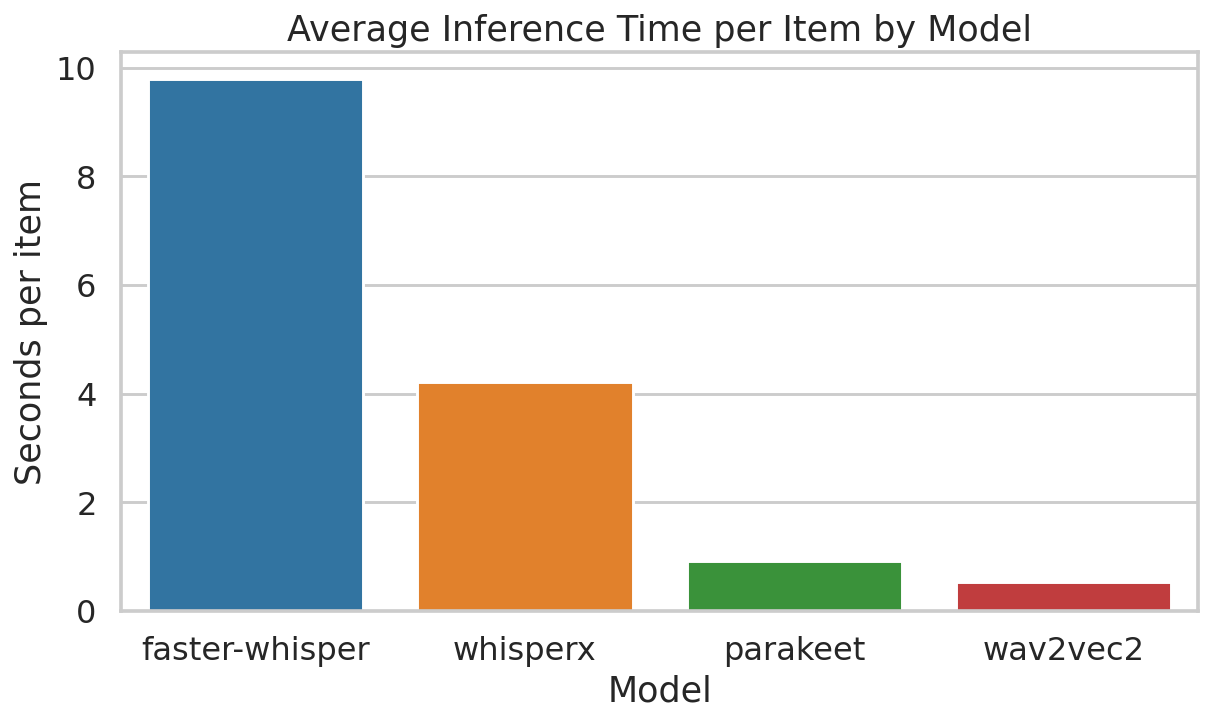

Saved plots to:
- /home/jamin/Year3Proj/Output/plot/snr_vs_mean_error_by_model_mixed_metric.png
- /home/jamin/Year3Proj/Output/plot/ovr_vs_mean_error_by_model_mixed_metric.png
- /home/jamin/Year3Proj/Output/plot/clip_by_clip_faster_whisper_vs_whisperx_cpwer.png
- /home/jamin/Year3Proj/Output/plot/metric_composition_by_model.png
- /home/jamin/Year3Proj/Output/plot/error_distribution_by_model_and_metric_family.png
- /home/jamin/Year3Proj/Output/plot/average_timing_per_item_by_model.png


In [6]:
def model_palette(model_names):
    return {model: MODEL_COLORS.get(model, "#333333") for model in model_names}


def plot_metric_vs_condition(data: pd.DataFrame, condition_col: str, title: str, ylabel: str, filename: str) -> None:
    plot_data = data.dropna(subset=[condition_col, "cross_model_error"]).copy()
    plot_data[condition_col] = pd.to_numeric(plot_data[condition_col], errors="coerce")
    plot_data = plot_data.dropna(subset=[condition_col])
    plot_data = plot_data.sort_values(condition_col)

    plt.figure(figsize=(11, 6))
    sns.lineplot(
        data=plot_data,
        x=condition_col,
        y="cross_model_error",
        hue="model",
        hue_order=MODEL_ORDER,
        palette=model_palette(MODEL_ORDER),
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        linewidth=2.2,
    )
    plt.title(title)
    plt.xlabel(condition_col.replace("_", " ").upper())
    plt.ylabel(ylabel)
    plt.legend(title="Model", frameon=True)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=200)
    plt.show()


def add_reference_line(ax):
    low, high = ax.get_xlim()
    ax.plot([low, high], [low, high], linestyle="--", color="#555555", linewidth=1)
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)


print("Plot helpers ready")

# Average inference time per item: total duration / total number of items.
timing_summary = (
    timings_df.groupby("model", as_index=False)
    .agg(total_duration_sec=("duration_sec", "sum"), total_items=("item_count", "sum"))
)
timing_summary["sec_per_item"] = timing_summary["total_duration_sec"] / timing_summary["total_items"]
timing_summary = timing_summary.sort_values("sec_per_item", ascending=False)

plt.figure(figsize=(9, 5.5))
sns.barplot(
    data=timing_summary,
    x="model",
    y="sec_per_item",
    order=timing_summary["model"],
    hue="model",
    hue_order=timing_summary["model"],
    palette=model_palette(timing_summary["model"]),
    legend=False,
)
plt.title("Average Inference Time per Item by Model")
plt.xlabel("Model")
plt.ylabel("Seconds per item")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "average_timing_per_item_by_model.png", dpi=200)
plt.show()

print("Saved plots to:")
for plot_name in [
    "snr_vs_mean_error_by_model_mixed_metric.png",
    "ovr_vs_mean_error_by_model_mixed_metric.png",
    "clip_by_clip_faster_whisper_vs_whisperx_cpwer.png",
    "metric_composition_by_model.png",
    "error_distribution_by_model_and_metric_family.png",
    "average_timing_per_item_by_model.png",
]:
    print(f"- {PLOTS_DIR / plot_name}")

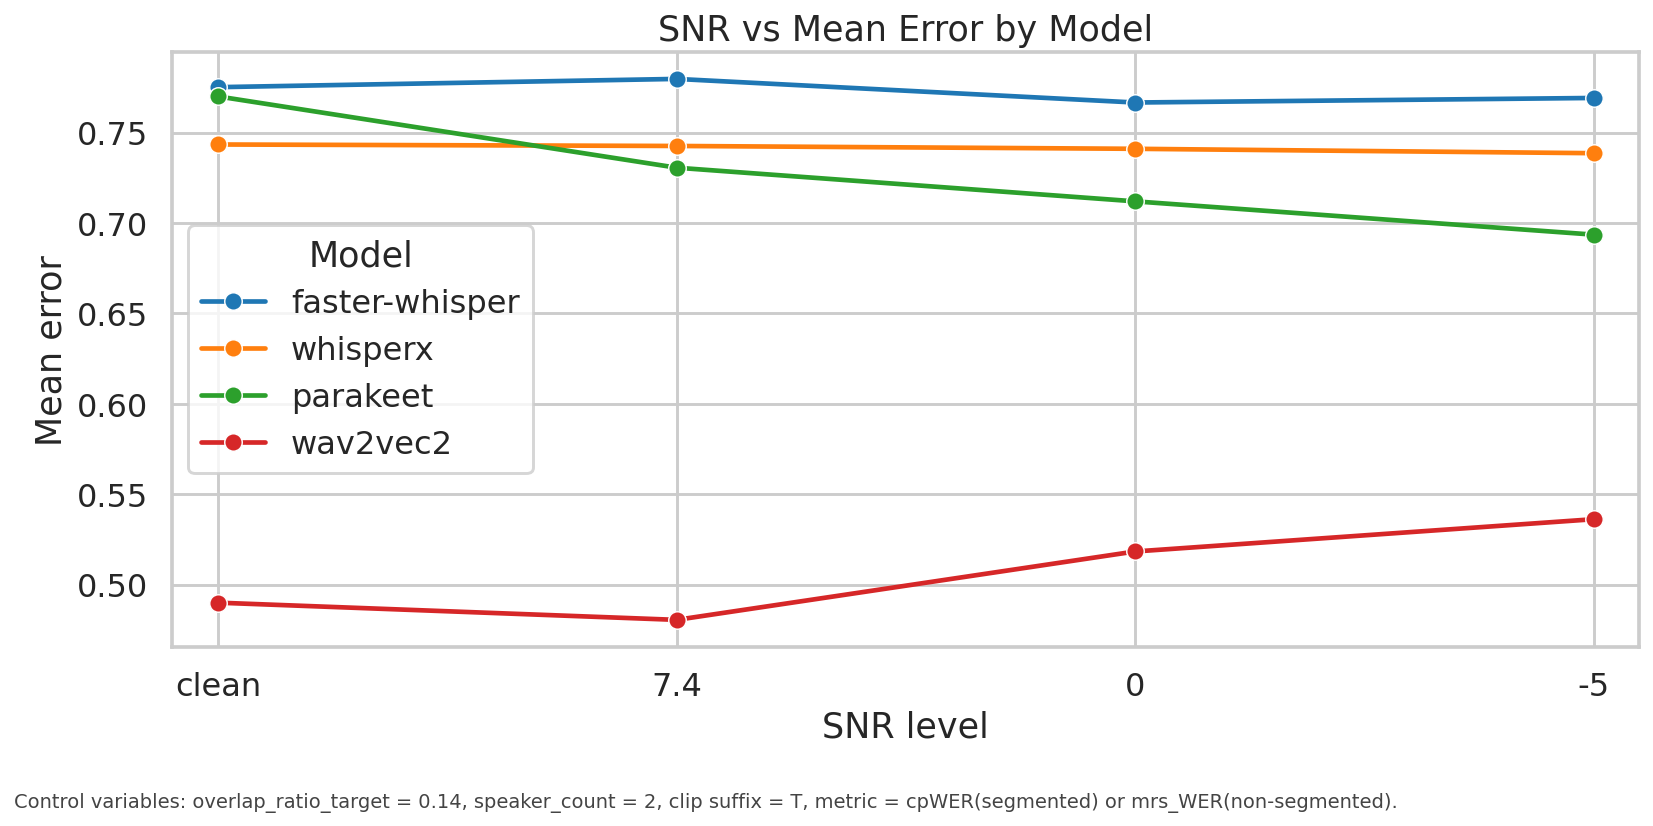

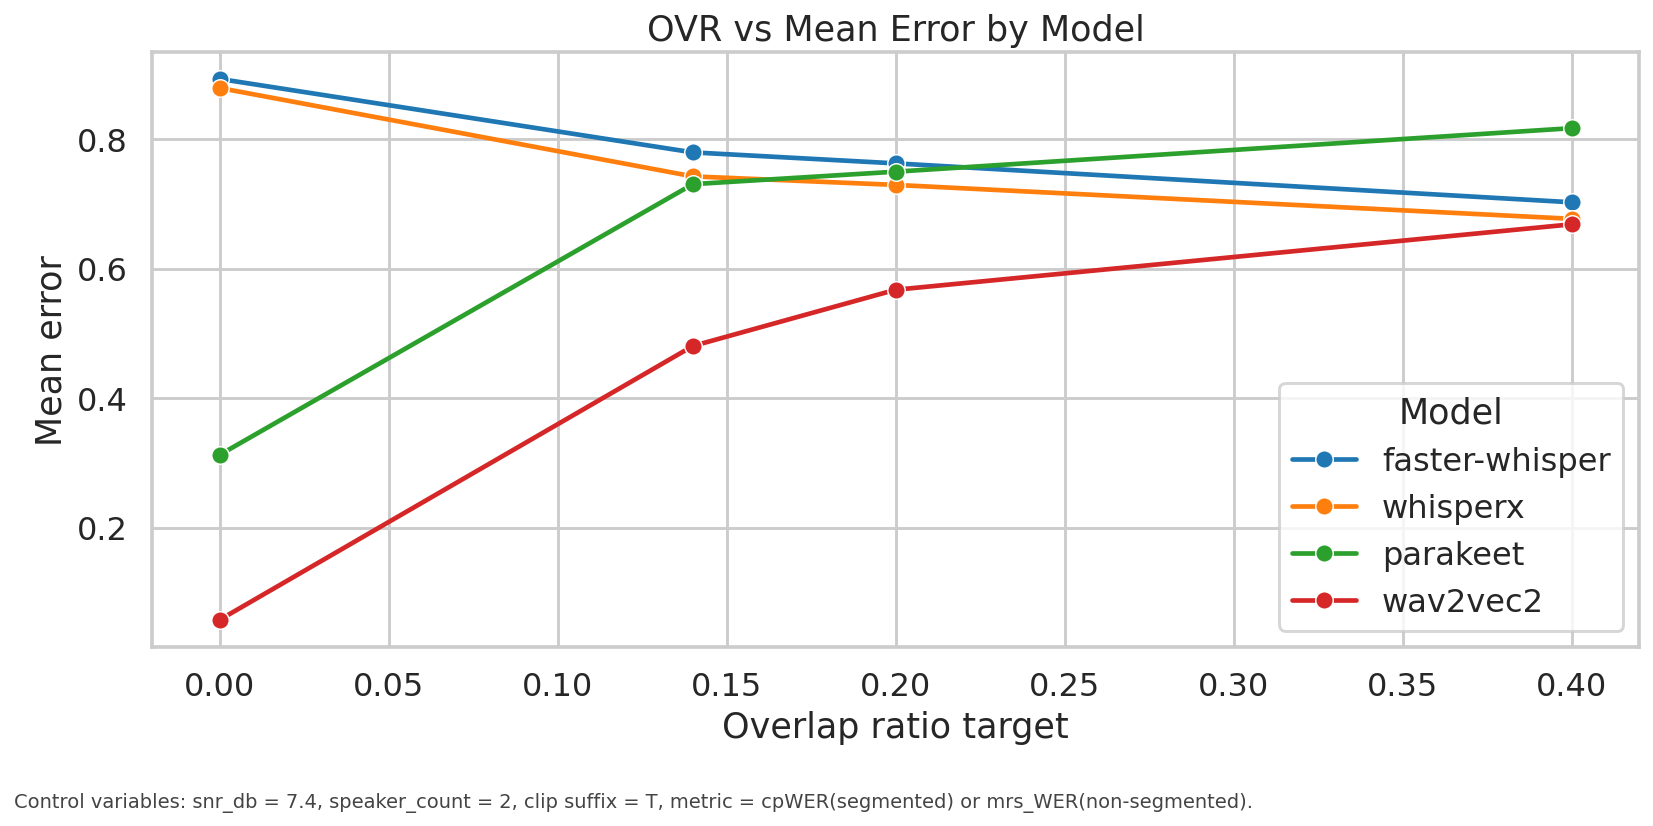

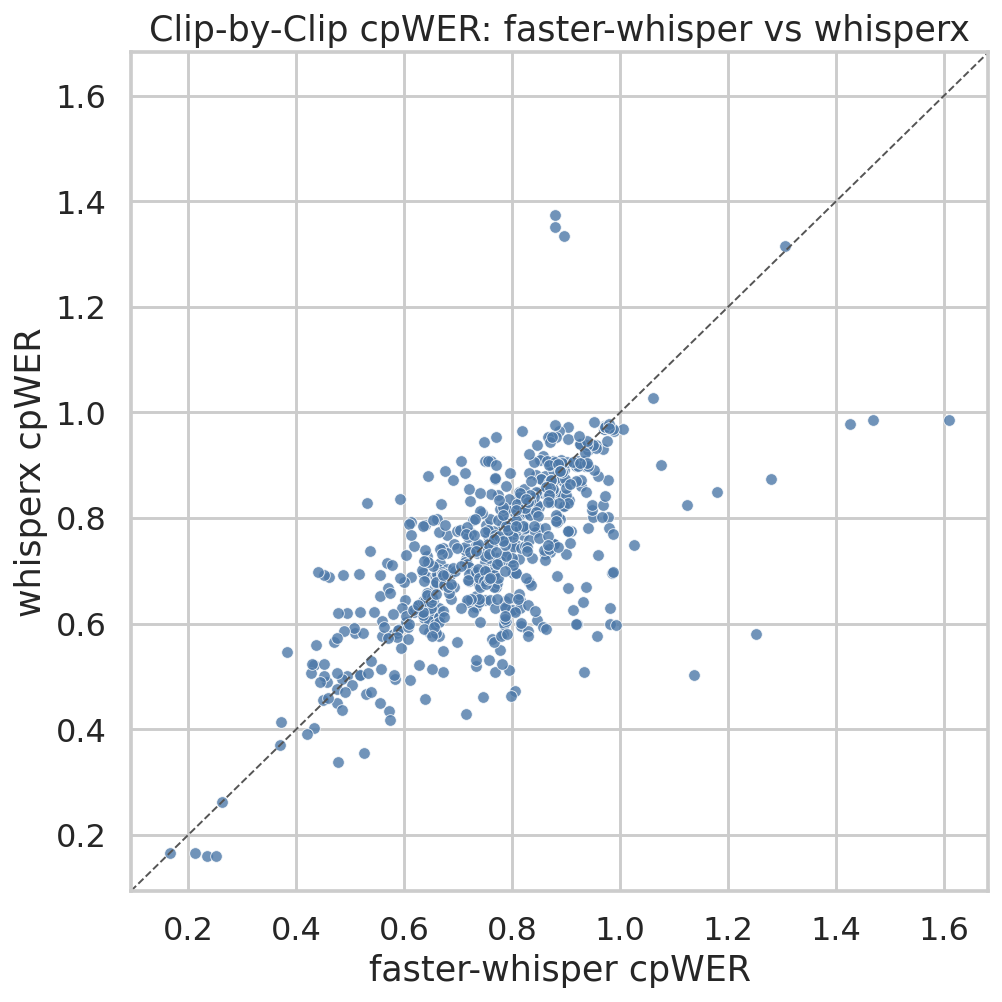

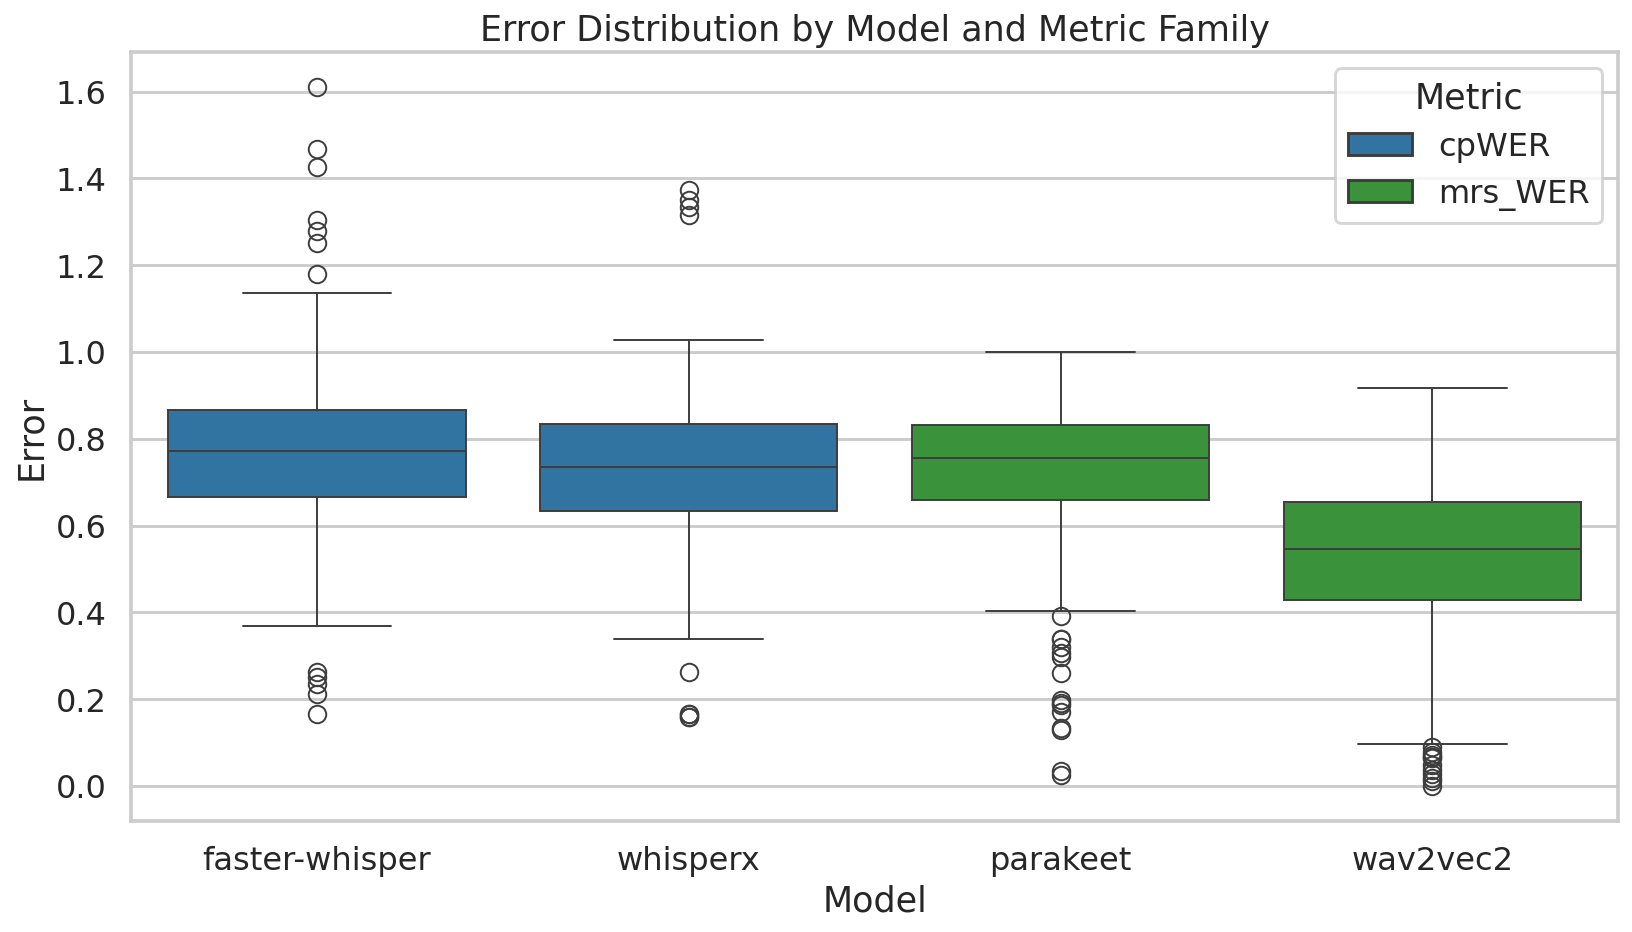

Saved plots to:
- /home/jamin/Year3Proj/Output/plot/snr_vs_mean_error_by_model_mixed_metric.png
- /home/jamin/Year3Proj/Output/plot/ovr_vs_mean_error_by_model_mixed_metric.png
- /home/jamin/Year3Proj/Output/plot/clip_by_clip_faster_whisper_vs_whisperx_cpwer.png
- /home/jamin/Year3Proj/Output/plot/error_distribution_by_model_and_metric_family.png


In [7]:
# SNR vs mean cross-model error with explicit order: clean, 7.4, 0, -5.
# Controlled setting for this plot: overlap_ratio_target = 0.14 (OVR fixed).
snr_order = ["clean", "7.4", "0", "-5"]
snr_pos = {label: idx for idx, label in enumerate(snr_order)}

snr_plot_df = successful_df.dropna(subset=["snr_label", "cross_model_error", "overlap_ratio_target"]).copy()
snr_plot_df["snr_label"] = snr_plot_df["snr_label"].astype(str)
snr_plot_df = snr_plot_df[snr_plot_df["snr_label"].isin(snr_order)]
snr_plot_df = snr_plot_df[np.isclose(snr_plot_df["overlap_ratio_target"].astype(float), 0.14)]

snr_summary = (
    snr_plot_df.groupby(["model", "snr_label"], as_index=False)["cross_model_error"]
    .mean()
)
snr_summary["snr_pos"] = snr_summary["snr_label"].map(snr_pos)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=snr_summary,
    x="snr_pos",
    y="cross_model_error",
    hue="model",
    hue_order=MODEL_ORDER,
    palette=model_palette(MODEL_ORDER),
    marker="o",
    linewidth=2.4,
)
plt.xticks([0, 1, 2, 3], snr_order)
plt.xlim(-0.1, 3.1)
plt.title("SNR vs Mean Error by Model")
plt.xlabel("SNR level")
plt.ylabel("Mean error")
plt.legend(title="Model")
snr_caption = "Control variables: overlap_ratio_target = 0.14, speaker_count = 2, clip suffix = T, metric = cpWER(segmented) or mrs_WER(non-segmented)."
plt.gcf().text(0.01, 0.01, snr_caption, fontsize=10, color="#444444")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(PLOTS_DIR / "snr_vs_mean_error_by_model_mixed_metric.png", dpi=200)
plt.show()

# OVR vs mean cross-model error for each model.
# Controlled setting for this plot: snr_db = 7.4 (SNR fixed).
ovr_plot_df = successful_df.dropna(subset=["overlap_ratio_target", "snr_label", "cross_model_error"]).copy()
ovr_plot_df["snr_label"] = ovr_plot_df["snr_label"].astype(str)
ovr_plot_df = ovr_plot_df[ovr_plot_df["snr_label"] == "7.4"]

ovr_summary = (
    ovr_plot_df.groupby(["model", "overlap_ratio_target"], as_index=False)["cross_model_error"]
    .mean()
    .sort_values(["model", "overlap_ratio_target"])
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=ovr_summary,
    x="overlap_ratio_target",
    y="cross_model_error",
    hue="model",
    hue_order=MODEL_ORDER,
    palette=model_palette(MODEL_ORDER),
    marker="o",
    linewidth=2.4,
)
plt.title("OVR vs Mean Error by Model")
plt.xlabel("Overlap ratio target")
plt.ylabel("Mean error")
plt.legend(title="Model")
ovr_caption = "Control variables: snr_db = 7.4, speaker_count = 2, clip suffix = T, metric = cpWER(segmented) or mrs_WER(non-segmented)."
plt.gcf().text(0.01, 0.01, ovr_caption, fontsize=10, color="#444444")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(PLOTS_DIR / "ovr_vs_mean_error_by_model_mixed_metric.png", dpi=200)
plt.show()

# Clip-by-clip comparison between faster-whisper and whisperx using cpWER only.
fw_whisperx = (
    results_df.loc[results_df["model"].isin(PAIRWISE_CPWER_MODELS) & (results_df["status"] == "success"),
                  ["clip_id", "model", "cpwer"]]
    .dropna()
    .pivot(index="clip_id", columns="model", values="cpwer")
    .dropna()
    .reset_index()
)

plt.figure(figsize=(7.5, 7.5))
ax = sns.scatterplot(
    data=fw_whisperx,
    x="faster-whisper",
    y="whisperx",
    s=36,
    alpha=0.8,
    color="#4c78a8",
)
add_reference_line(ax)
plt.title("Clip-by-Clip cpWER: faster-whisper vs whisperx")
plt.xlabel("faster-whisper cpWER")
plt.ylabel("whisperx cpWER")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "clip_by_clip_faster_whisper_vs_whisperx_cpwer.png", dpi=200)
plt.show()

# Useful interpretation plot 1: metric composition by model (how much cpWER vs mrs_WER contributes).
metric_mix = (
    successful_df.groupby(["model", "cross_metric_name"], as_index=False)["clip_id"]
    .count()
    .rename(columns={"clip_id": "clips"})
)
metric_pivot = metric_mix.pivot(index="model", columns="cross_metric_name", values="clips").fillna(0)
metric_ratio = metric_pivot.div(metric_pivot.sum(axis=1), axis=0).reset_index()
metric_ratio_long = metric_ratio.melt(id_vars="model", var_name="metric", value_name="ratio")


# Useful interpretation plot 2: error distribution split by metric family.
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=successful_df,
    x="model",
    y="cross_model_error",
    hue="cross_metric_name",
    order=MODEL_ORDER,
    hue_order=["cpWER", "mrs_WER"],
    palette={"cpWER": "#1f77b4", "mrs_WER": "#2ca02c"},
)
plt.title("Error Distribution by Model and Metric Family")
plt.xlabel("Model")
plt.ylabel("Error")
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "error_distribution_by_model_and_metric_family.png", dpi=200)
plt.show()

print("Saved plots to:")
for plot_name in [
    "snr_vs_mean_error_by_model_mixed_metric.png",
    "ovr_vs_mean_error_by_model_mixed_metric.png",
    "clip_by_clip_faster_whisper_vs_whisperx_cpwer.png",
    "error_distribution_by_model_and_metric_family.png"
]:
    print(f"- {PLOTS_DIR / plot_name}")

Transferability comparison: synthetic -> real


,model,real_metric,synthetic_metric,real_count,synthetic_total,synthetic_successful,synthetic_success_rate,real_mean,synthetic_mean,gap_real_minus_synth,ratio_real_over_synth,synthetic_rank,real_rank,rank_shift_real_minus_synth
0,parakeet,wer,wer,100,3720,610,0.1640,0.3886,0.7385,-0.3499,0.5262,3.0,1.0,-2.0
1,wav2vec2,wer,wer,100,3720,3720,1.0000,0.7228,0.6622,0.0606,1.0915,1.0,2.0,1.0
2,whisperx,cpwer,cpwer,100,3720,628,0.1688,0.8355,0.7369,0.0986,1.1339,2.0,3.0,1.0
3,faster-whisper,cpwer,cpwer,100,3720,1689,0.4540,0.8949,0.7719,0.1231,1.1594,4.0,4.0,0.0


/tmp/ipykernel_53080/3757613215.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


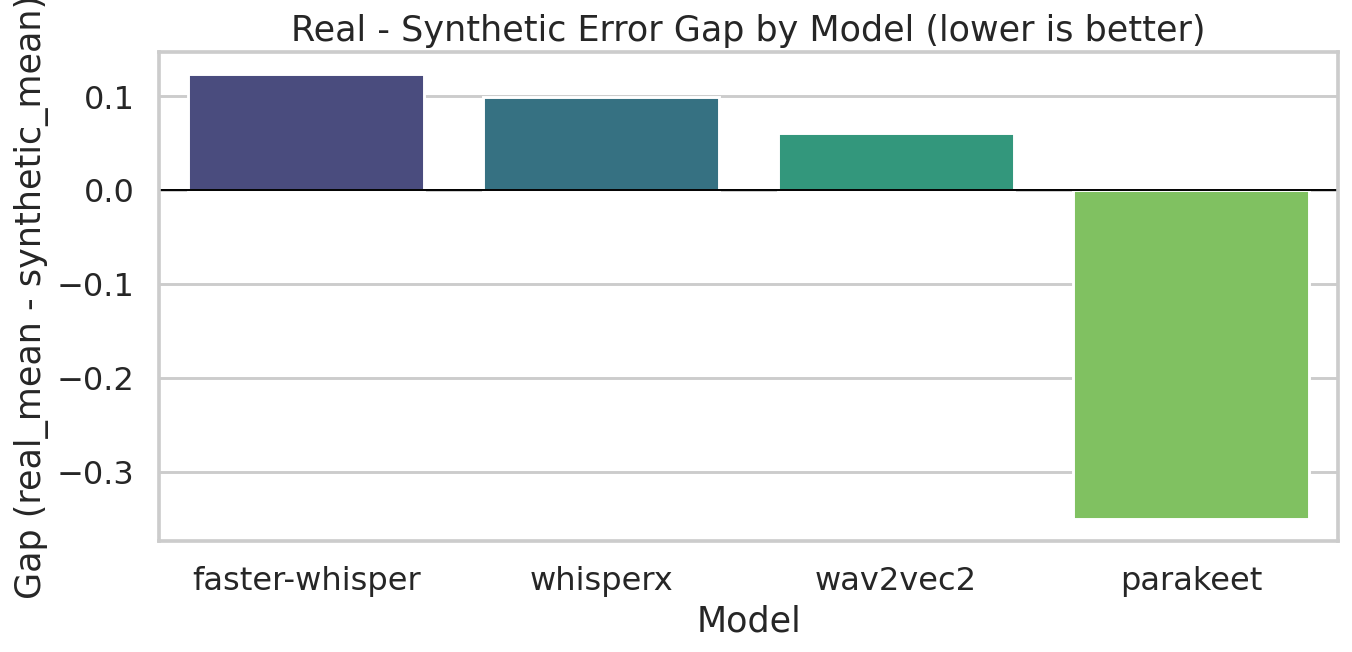

Mean relative degradation (real vs synthetic): -2.22%


In [8]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("/home/jamin/Year3Proj")
REAL_EVAL_PATH = ROOT / "Output" / "real_eval_results.json"
SYN_DIR = ROOT / "WER_Results_by_Model"

with open(REAL_EVAL_PATH, "r", encoding="utf-8") as f:
    real_eval = json.load(f)

# Build real-data stats from per-clip entries so we preserve metric type per model.
real_rows = []
for clip_id, per_model in real_eval.get("by_clip", {}).items():
    for model_name, result in per_model.items():
        real_rows.append(
            {
                "clip_id": clip_id,
                "model": model_name,
                "metric": result.get("metric"),
                "score": result.get("score"),
            }
        )

real_df = pd.DataFrame(real_rows)
if real_df.empty:
    raise RuntimeError("No real-data evaluation rows found in Output/real_eval_results.json")

real_model_summary = (
    real_df.groupby("model")
    .agg(
        real_count=("score", "size"),
        real_mean=("score", "mean"),
        real_median=("score", "median"),
        real_min=("score", "min"),
        real_max=("score", "max"),
    )
    .reset_index()
)

real_metric_mode = (
    real_df.groupby("model")["metric"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .reset_index(name="real_metric")
)
real_model_summary = real_model_summary.merge(real_metric_mode, on="model", how="left")


def _pick_synthetic_mean(summary: dict, preferred_metric: str):
    """Pick a synthetic mean metric compatible with real metric for fair transferability comparison."""
    if preferred_metric == "cpwer":
        if "cpwer_mean" in summary:
            return "cpwer", summary["cpwer_mean"]
        if "wer_segmented_mean" in summary:
            return "wer_segmented", summary["wer_segmented_mean"]
        if "wer_mean" in summary:
            return "wer", summary["wer_mean"]
    else:
        if "wer_mean" in summary:
            return "wer", summary["wer_mean"]
        if "wer_segmented_mean" in summary:
            return "wer_segmented", summary["wer_segmented_mean"]
        if "cpwer_mean" in summary:
            return "cpwer", summary["cpwer_mean"]

    for key in ("wer_mean", "wer_segmented_mean", "cpwer_mean"):
        if key in summary:
            return key.replace("_mean", ""), summary[key]
    return None, np.nan


syn_rows = []
for model_file in sorted(SYN_DIR.glob("*_wer_results.json")):
    with open(model_file, "r", encoding="utf-8") as f:
        payload = json.load(f)

    model = payload.get("model")
    summary = payload.get("summary", {})

    # If model is missing in real summary, we still keep synthetic row.
    preferred_metric = (
        real_model_summary.loc[real_model_summary["model"] == model, "real_metric"].iloc[0]
        if model in set(real_model_summary["model"])
        else "wer"
    )
    syn_metric, syn_mean = _pick_synthetic_mean(summary, preferred_metric)

    syn_rows.append(
        {
            "model": model,
            "synthetic_metric": syn_metric,
            "synthetic_mean": syn_mean,
            "synthetic_total": summary.get("total", np.nan),
            "synthetic_successful": summary.get("successful", np.nan),
            "synthetic_success_rate": (
                (summary.get("successful", 0) / summary.get("total", 1))
                if summary.get("total", 0)
                else np.nan
            ),
        }
    )

syn_df = pd.DataFrame(syn_rows)

transfer_df = real_model_summary.merge(syn_df, on="model", how="outer")
transfer_df["gap_real_minus_synth"] = transfer_df["real_mean"] - transfer_df["synthetic_mean"]
transfer_df["ratio_real_over_synth"] = transfer_df["real_mean"] / transfer_df["synthetic_mean"]

# Lower is better for WER/cpWER, so positive gap means degradation on real data.
transfer_df["synthetic_rank"] = transfer_df["synthetic_mean"].rank(method="min")
transfer_df["real_rank"] = transfer_df["real_mean"].rank(method="min")
transfer_df["rank_shift_real_minus_synth"] = transfer_df["real_rank"] - transfer_df["synthetic_rank"]

transfer_df = transfer_df.sort_values("real_mean", ascending=True).reset_index(drop=True)

cols = [
    "model",
    "real_metric",
    "synthetic_metric",
    "real_count",
    "synthetic_total",
    "synthetic_successful",
    "synthetic_success_rate",
    "real_mean",
    "synthetic_mean",
    "gap_real_minus_synth",
    "ratio_real_over_synth",
    "synthetic_rank",
    "real_rank",
    "rank_shift_real_minus_synth",
]

print("Transferability comparison: synthetic -> real")
display(transfer_df[cols].round(4))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=transfer_df.sort_values("gap_real_minus_synth", ascending=False),
    x="model",
    y="gap_real_minus_synth",
    palette="viridis",
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Real - Synthetic Error Gap by Model (lower is better)")
plt.ylabel("Gap (real_mean - synthetic_mean)")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

# Weighted headline figure: average relative degradation across comparable models.
valid = transfer_df.dropna(subset=["ratio_real_over_synth"])
if not valid.empty:
    rel_deg = (valid["ratio_real_over_synth"] - 1.0) * 100.0
    print(f"Mean relative degradation (real vs synthetic): {rel_deg.mean():.2f}%")


Transferability by overlap ratio


,model,ovr_label,clips,real_metric,real_mean,synthetic_mean,gap_real_minus_synth
0,faster-whisper,0.00,10,cpwer,0.8949,0.8933,0.0017
1,faster-whisper,0.14,400,cpwer,0.8949,0.7727,0.1223
2,faster-whisper,0.20,100,cpwer,0.8949,0.7627,0.1322
3,faster-whisper,0.40,100,cpwer,0.8949,0.7026,0.1924
4,parakeet,0.00,10,wer,0.3886,0.3122,0.0763
5,parakeet,0.14,400,wer,0.3886,0.7266,-0.3380
6,parakeet,0.20,100,wer,0.3886,0.7499,-0.3614
7,parakeet,0.40,100,wer,0.3886,0.8172,-0.4286
8,wav2vec2,0.00,10,wer,0.7228,0.0573,0.6656
9,wav2vec2,0.14,400,wer,0.7228,0.5063,0.2166


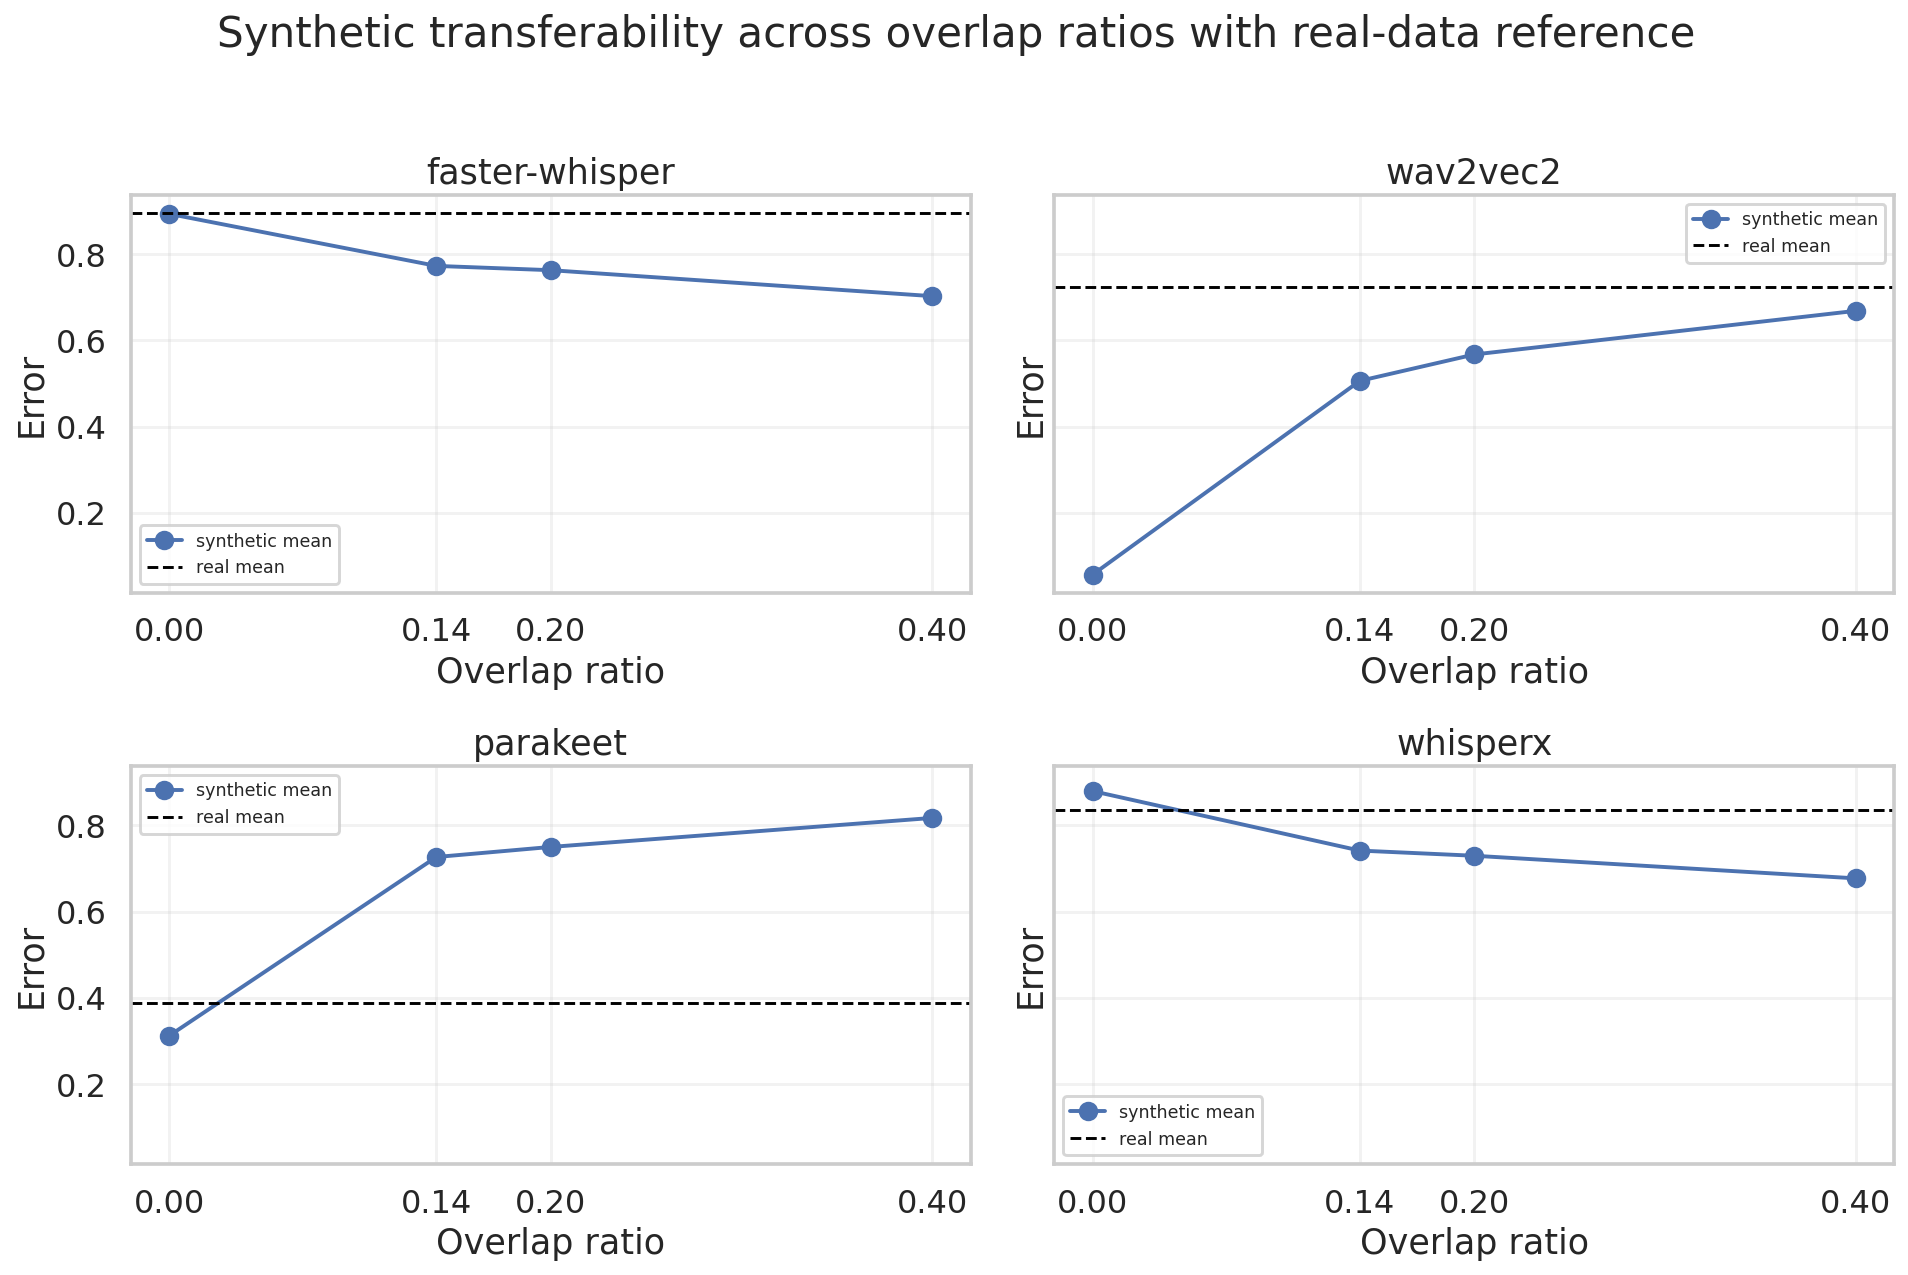

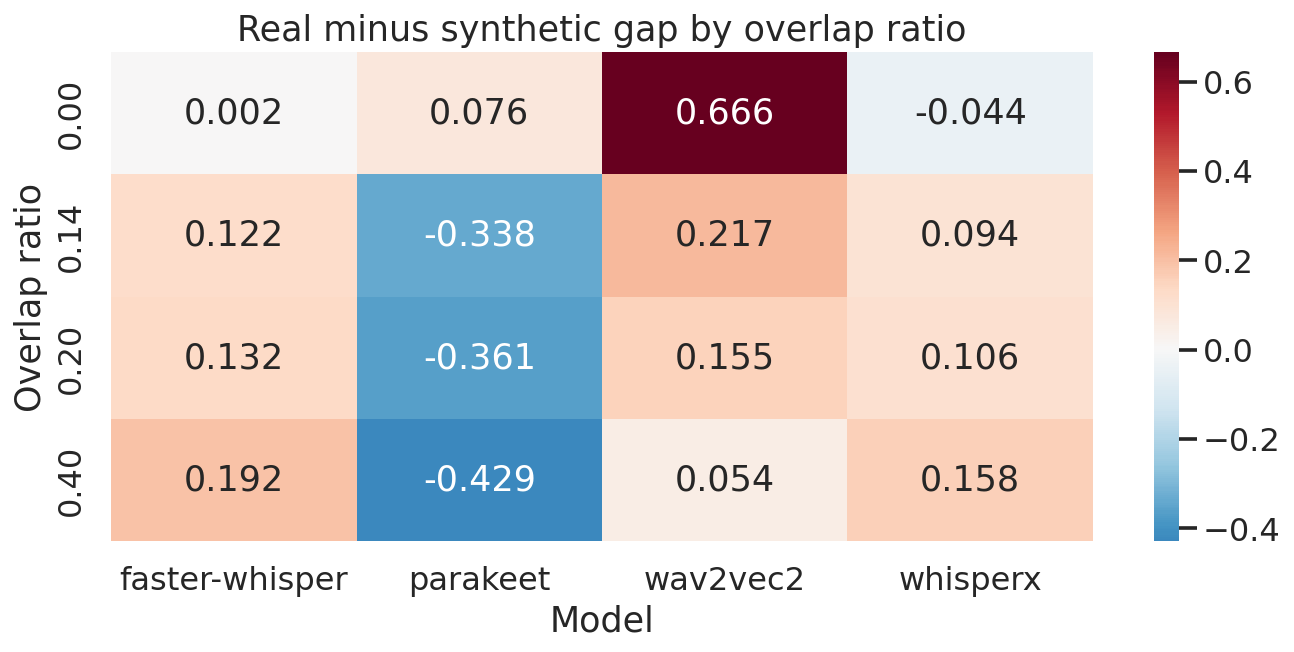

In [9]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("/home/jamin/Year3Proj")
REAL_EVAL_PATH = ROOT / "Output" / "real_eval_results.json"
MANIFEST_PATH = ROOT / "Output" / "manifest.csv"
SYN_DIR = ROOT / "WER_Results_by_Model"
CROSS_MODEL_CLIP_REGEX = r"(^mix_[0-9]+_0\.(00|14|20|40)_2_7\.4_T$)|(^mix_[0-9]+_0\.14_2_(None|7\.4|0|-5)_T$)"


def _pick_mean(summary: dict, preferred_metric: str):
    if preferred_metric == "cpwer":
        if "cpwer_mean" in summary:
            return "cpwer", summary["cpwer_mean"]
        if "wer_segmented_mean" in summary:
            return "wer_segmented", summary["wer_segmented_mean"]
        if "wer_mean" in summary:
            return "wer", summary["wer_mean"]
    else:
        if "wer_mean" in summary:
            return "wer", summary["wer_mean"]
        if "wer_segmented_mean" in summary:
            return "wer_segmented", summary["wer_segmented_mean"]
        if "cpwer_mean" in summary:
            return "cpwer", summary["cpwer_mean"]

    for key in ("wer_mean", "wer_segmented_mean", "cpwer_mean"):
        if key in summary:
            return key.replace("_mean", ""), summary[key]
    return None, np.nan


def _real_summary_from_eval(real_eval_path: Path) -> pd.DataFrame:
    with open(real_eval_path, "r", encoding="utf-8") as f:
        real_eval = json.load(f)

    rows = []
    for clip_id, per_model in real_eval.get("by_clip", {}).items():
        for model_name, result in per_model.items():
            rows.append(
                {
                    "clip_id": clip_id,
                    "model": model_name,
                    "metric": result.get("metric"),
                    "score": result.get("score"),
                }
            )

    real_df = pd.DataFrame(rows)
    if real_df.empty:
        raise RuntimeError("No rows found in Output/real_eval_results.json")

    real_summary = (
        real_df.groupby("model")
        .agg(
            real_count=("score", "size"),
            real_mean=("score", "mean"),
            real_median=("score", "median"),
        )
        .reset_index()
    )
    real_metric_mode = (
        real_df.groupby("model")["metric"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
        .reset_index(name="real_metric")
    )
    return real_summary.merge(real_metric_mode, on="model", how="left")


manifest_df = pd.read_csv(MANIFEST_PATH)
manifest_df = manifest_df[manifest_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)].copy()
if "overlap_ratio_target" not in manifest_df.columns:
    raise RuntimeError("Manifest is missing overlap_ratio_target; cannot build OVR comparison.")
manifest_df["ovr_label"] = manifest_df["overlap_ratio_target"].map(lambda value: f"{float(value):.2f}" if pd.notna(value) else "unknown")

real_model_summary_ovr = _real_summary_from_eval(REAL_EVAL_PATH)

synthetic_rows = []
for result_path in sorted(SYN_DIR.glob("*_wer_results.json")):
    with open(result_path, "r", encoding="utf-8") as f:
        payload = json.load(f)

    model = payload.get("model", result_path.stem.replace("_wer_results", ""))
    summary = payload.get("summary", {})
    preferred_metric = (
        real_model_summary_ovr.loc[real_model_summary_ovr["model"] == model, "real_metric"].iloc[0]
        if model in set(real_model_summary_ovr["model"])
        else "wer"
    )
    synthetic_metric, synthetic_mean = _pick_mean(summary, preferred_metric)
    synthetic_rows.append(
        {
            "model": model,
            "synthetic_metric": synthetic_metric,
            "synthetic_mean": synthetic_mean,
        }
    )

synthetic_model_summary = pd.DataFrame(synthetic_rows)

# Load the per-clip synthetic results so we can compare across overlap ratios.
clip_rows = []
for result_path in sorted(SYN_DIR.glob("*_wer_results.json")):
    with open(result_path, "r", encoding="utf-8") as f:
        payload = json.load(f)

    model = payload.get("model", result_path.stem.replace("_wer_results", ""))
    for item in payload.get("results", []):
        if item.get("status") != "success":
            continue
        metrics = item.get("metrics", {})
        clip_rows.append(
            {
                "model": model,
                "clip_id": item.get("clip_id"),
                "metric_type": item.get("metric_type"),
                "cross_error": metrics.get("cpwer") if pd.notna(metrics.get("cpwer", np.nan)) else metrics.get("wer"),
                "cpwer": metrics.get("cpwer", np.nan),
                "wer": metrics.get("wer", np.nan),
            }
        )

synthetic_clip_df = pd.DataFrame(clip_rows)
synthetic_clip_df = synthetic_clip_df[synthetic_clip_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)].copy()
synthetic_clip_df = synthetic_clip_df.merge(manifest_df[["clip_id", "overlap_ratio_target", "ovr_label"]], on="clip_id", how="left")
synthetic_clip_df["synthetic_metric"] = np.where(pd.notna(synthetic_clip_df["cpwer"]), "cpwer", "wer")
synthetic_clip_df["synthetic_error"] = np.where(pd.notna(synthetic_clip_df["cpwer"]), synthetic_clip_df["cpwer"], synthetic_clip_df["wer"])

ovr_compare_df = (
    synthetic_clip_df.groupby(["model", "overlap_ratio_target", "ovr_label"], as_index=False)
    .agg(
        synthetic_mean=("synthetic_error", "mean"),
        clips=("clip_id", "count"),
    )
    .merge(real_model_summary_ovr[["model", "real_mean", "real_metric"]], on="model", how="left")
)
ovr_compare_df["gap_real_minus_synth"] = ovr_compare_df["real_mean"] - ovr_compare_df["synthetic_mean"]
ovr_compare_df = ovr_compare_df.sort_values(["model", "overlap_ratio_target"]).reset_index(drop=True)

print("Transferability by overlap ratio")
display(
    ovr_compare_df[
        ["model", "ovr_label", "clips", "real_metric", "real_mean", "synthetic_mean", "gap_real_minus_synth"]
    ].round(4)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes = axes.ravel()
for ax, model in zip(axes, ["faster-whisper", "wav2vec2", "parakeet", "whisperx"]):
    model_df = ovr_compare_df[ovr_compare_df["model"] == model].copy()
    if model_df.empty:
        ax.set_axis_off()
        continue

    x = model_df["overlap_ratio_target"].astype(float)
    ax.plot(x, model_df["synthetic_mean"], marker="o", linewidth=2, label="synthetic mean")
    ax.axhline(model_df["real_mean"].iloc[0], linestyle="--", color="black", linewidth=1.5, label="real mean")
    ax.set_title(model)
    ax.set_xlabel("Overlap ratio")
    ax.set_ylabel("Error")
    ax.set_xticks(sorted(model_df["overlap_ratio_target"].astype(float).unique()))
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9)

plt.suptitle("Synthetic transferability across overlap ratios with real-data reference", y=1.02)
plt.tight_layout()
plt.show()

pivot_gap = ovr_compare_df.pivot_table(
    index="ovr_label",
    columns="model",
    values="gap_real_minus_synth",
    aggfunc="mean",
)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_gap.sort_index(), annot=True, fmt=".3f", cmap="RdBu_r", center=0)
plt.title("Real minus synthetic gap by overlap ratio")
plt.xlabel("Model")
plt.ylabel("Overlap ratio")
plt.tight_layout()
plt.show()
